In [1]:
learning_rate = 0.01
epochs = 100000
hidden = 32

Net(
  (fc1): Linear(in_features=1, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)
[Parameter containing:
tensor([[-0.4326],
        [-0.7497],
        [-0.7310],
        [ 0.6067],
        [ 0.8160],
        [ 0.5871],
        [ 0.9884],
        [ 0.5002],
        [ 0.7031],
        [-0.1103],
        [-0.1464],
        [-0.1929],
        [-0.2791],
        [-0.2377],
        [-0.3093],
        [-0.4164],
        [-0.5381],
        [ 0.8081],
        [-0.8054],
        [ 0.1122],
        [ 0.8636],
        [ 0.9959],
        [ 0.4934],
        [-0.9624],
        [-0.9974],
        [ 0.4604],
        [ 0.9230],
        [ 0.8809],
        [-0.2079],
        [ 0.3266],
        [ 0.2646],
        [ 0.8993]], requires_grad=True), Parameter containing:
tensor([-0.9523, -0.7778,  0.2815, -0.9886,  0.3184,  0.6796, -0.7567, -0.4542,
         0.4518,  0.9824, -0.4668, -0.6360,  0.2060, -0.1714

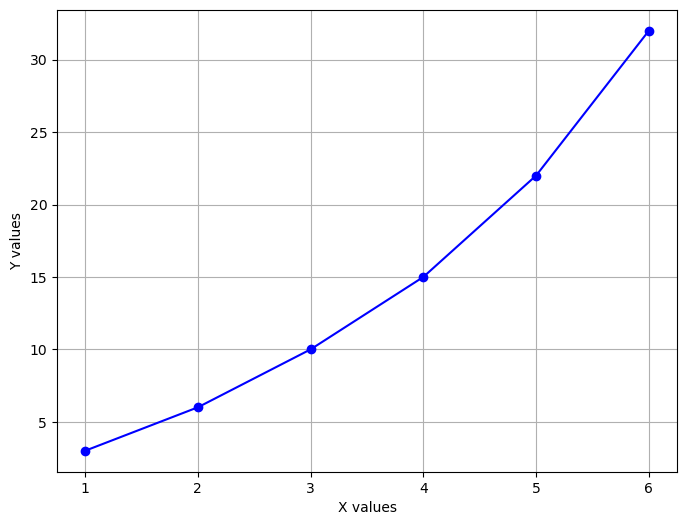

In [2]:
### Training with fancier version ###

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim
import matplotlib.pyplot as plt

class Net(nn.Module): ## nn.Module class is used
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(1,hidden)  # in dim, out dim
        self.fc2 = nn.Linear(hidden,hidden)
        self.fc3 = nn.Linear(hidden,1)
        
    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        return x

net = Net()

print(net)
print(list(net.parameters())) # parameters are randomized


#def criterion(out, label):
#    return (label - out)**2
criterion = nn.MSELoss()


optimizer = optim.Adam(net.parameters(), lr=learning_rate)
#optimizer = optim.Adam(net.parameters(), lr=0.1)


data = [(1.0,3.0), (2.0,6.0), (3.0,10.0), (4.0,15.0), (5.0,22.0), (6.0,32.0)]

# Split data into x and y
x_values, y_values = zip(*data)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(x_values, y_values, marker='o', linestyle='-', color='b')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.grid(True)
plt.show()

In [3]:
for epoch in range(epochs):
    for i, current_data in enumerate(data):
        X, Y = current_data
        X, Y = torch.FloatTensor([X]), torch.FloatTensor([Y])
        optimizer.zero_grad()   
        outputs = net(X)
        loss = criterion(outputs, Y)
        loss.backward()
        optimizer.step()    ## This line is equivalent to "W = W - lr* W.grad"
    if loss < 1e-5: # set the exit condition
        print("Epoch {} - loss: {}".format(epoch, loss))
        break
    if epoch%10 == 0:
        print("Epoch {} - loss: {}".format(epoch, loss))


### Test the trained network ###            
for i, current_data in enumerate(data):
    X, Y = current_data
    X, Y = torch.FloatTensor([X]), torch.FloatTensor([Y])  
    out = net(torch.FloatTensor(X))  
    print("when x = {}, y = {}".format(X, out))
    

Epoch 0 - loss: 772.8312377929688
Epoch 10 - loss: 30.37603759765625
Epoch 20 - loss: 24.1579647064209
Epoch 30 - loss: 16.352922439575195
Epoch 40 - loss: 10.986724853515625
Epoch 50 - loss: 7.709729194641113
Epoch 60 - loss: 5.733405590057373
Epoch 70 - loss: 4.623113632202148
Epoch 80 - loss: 3.499321699142456
Epoch 90 - loss: 2.595020055770874
Epoch 100 - loss: 1.8554480075836182
Epoch 110 - loss: 1.1711384057998657
Epoch 120 - loss: 0.9562502503395081
Epoch 130 - loss: 0.774344801902771
Epoch 140 - loss: 0.6061477661132812
Epoch 150 - loss: 0.4546254575252533
Epoch 160 - loss: 0.2881239354610443
Epoch 170 - loss: 0.001347818411886692
Epoch 180 - loss: 0.006866252515465021
Epoch 190 - loss: 0.33316856622695923
Epoch 200 - loss: 0.3276669681072235
Epoch 210 - loss: 0.22275890409946442
Epoch 220 - loss: 0.16833612322807312
Epoch 230 - loss: 1.888165831565857
Epoch 240 - loss: 0.0010119244689121842
Epoch 250 - loss: 0.659013032913208
Epoch 260 - loss: 0.5704500675201416
Epoch 270 - lo

In [4]:
X

tensor([6.])

In [5]:
W = torch.tensor([1.0], requires_grad=True)
W = W*2
label = 1.0
loss = W*5 - label 
loss.backward()
W.grad

/tmp/ipykernel_7591/353321738.py:6: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  W.grad
